Name: Sadat Maliha Mashiat

Email: sadatmaliha703@gmail.com

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

# Q1.

In [ ]:
df = pd.read_csv('titanic_data_updated.csv')

display(df.shape)

display(df.head(10))

display(df.sample(5))


(891, 12)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,no,third,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,yes,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,yes,third,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,yes,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,no,third,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,no,third,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,no,first,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,no,third,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,yes,third,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,yes,second,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
301,302,yes,third,"McCoy, Mr. Bernard",male,NaN,2,0,367226,23.2500,NaN,Q
454,455,no,third,"Peduzzi, Mr. Joseph",male,NaN,0,0,A/5 2817,8.0500,NaN,S
442,443,no,third,"Petterson, Mr. Johan Emil",male,25.0,1,0,347076,7.7750,NaN,S
1,2,yes,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
492,493,no,first,"Molson, Mr. Harry Markland",male,55.0,0,0,113787,30.5000,C30,S


# Q2.

In [ ]:
display(df.isnull().sum())

display(df.duplicated().sum())

df.drop_duplicates(inplace=True)



,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


np.int64(0)

# Q3.

In [ ]:
df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    object 
 2   Pclass       891 non-null    object 
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(3), object(7)
memory usage: 83.7+ KB


,PassengerId,Age,SibSp,Parch,Fare
count,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,29.699118,0.523008,0.381594,32.204208
std,257.353842,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,38.000000,1.000000,0.000000,31.000000
max,891.000000,80.000000,8.000000,6.000000,512.329200


Observation - 01: We can see seven columns consist with categorical values and remaining columns are numerical.

Observation - 02: Some passengers paid 0 fare and some paid high fare. So we can say there is high variation and outliers in Fare column.

# Q4.

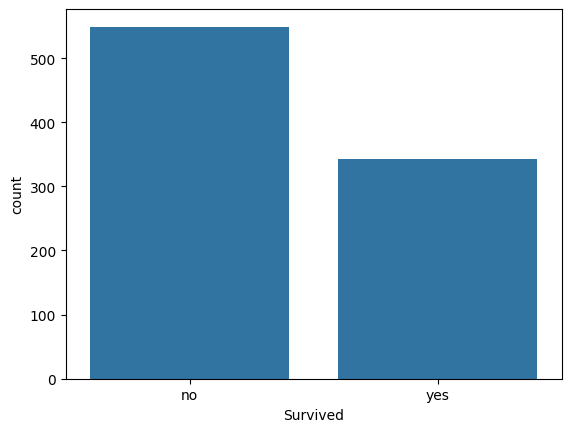

,count
Survived,
no,61.616162
yes,38.383838


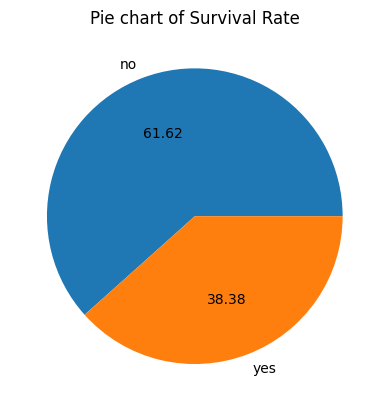

In [ ]:
sns.countplot(data = df, x = df['Survived'])
plt.show()

display((df['Survived'].value_counts() / len(df) ) * 100)

survived_count = df['Survived'].value_counts()
survived_label = df['Survived'].unique()

plt.pie(survived_count, labels = survived_label, autopct="%1.2f")
plt.title('Pie chart of Survival Rate')
plt.show()

Insight - 01: We can say that most passengers did not survived as "no" category has highest count.

Insight - 02: So the "Survived" column is imbalanced.

# Q5.

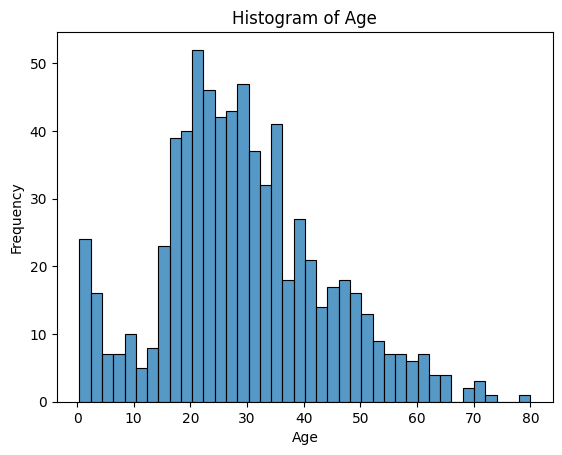

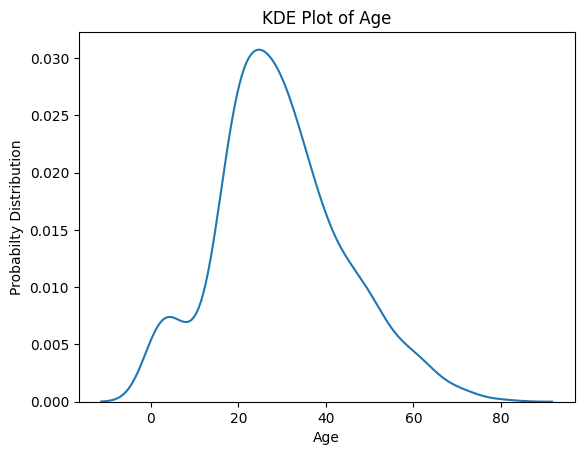

In [ ]:
sns.histplot(df['Age'], bins = 40)

plt.title('Histogram of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

sns.kdeplot(df['Age'])
plt.title('KDE Plot of Age')
plt.xlabel('Age')
plt.ylabel('Probabilty Distribution')
plt.show()

Observation - 01: Age column is not normally distributed. It seems to be right skewed.

Observation - 02: This column also has outliers and the highest numbers of passengers are around 25 years old.

# Q6.

Sex     Survived
female  yes         0.742038
        no          0.257962
male    no          0.811092
        yes         0.188908
Name: proportion, dtype: float64


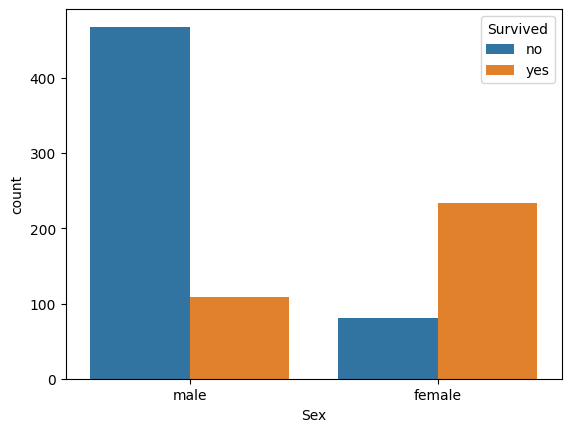

In [ ]:
sns.countplot(x = df['Sex'], hue = df['Survived'])

gender_split = df.groupby('Sex')['Survived'].value_counts(normalize = True)

print(gender_split)

Insight - 01: It is observed that gender has significant impact on survival rate of passengers.

Insight - 02: About 74.2% female survived whereas about 81.1% male passengers did not survive.

# Q7.

<Axes: xlabel='Pclass', ylabel='Fare'>

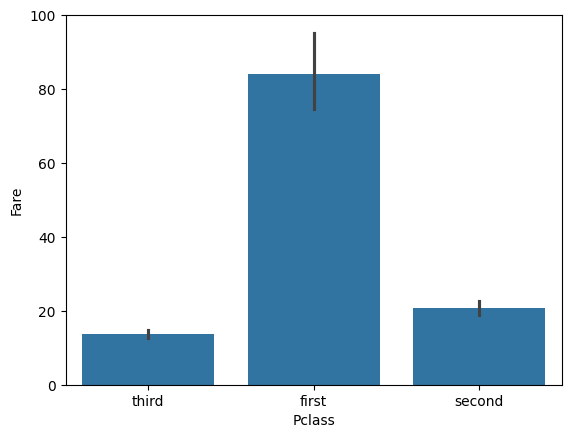

In [ ]:
sns.barplot(x = df['Pclass'], y = df['Fare'])

Observation - 01: "First Class" has the highest fare.

Observation - 02: The average fare decreases as the passenger class changes from first to third class.

# Q8.

<Axes: xlabel='Age', ylabel='Density'>

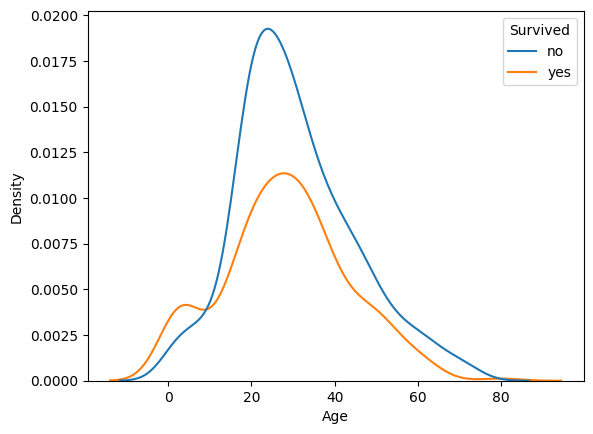

In [ ]:
sns.kdeplot(data = df, x = 'Age', hue = 'Survived')

Insight - 01: Both distributions are right skewed with small number of passengers at older ages.

Insight - 02: The highest density of both survivors and non-survivors is around 25-30 years old.

# Q9.

In [ ]:
df.drop(['PassengerId', 'Name', 'Ticket'], axis = 1, inplace = True)

X = df.drop(['Survived'], axis = 1)

Y = df['Survived']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42)

display(X_train.shape)
display(X_test.shape)

display(Y_train.shape)
display(Y_test.shape)

(712, 8)

(179, 8)

(712,)

(179,)

# Q10.

In [ ]:

#Age
age_imputer = SimpleImputer(missing_values = np.nan, strategy = 'mean')
age_imputer.fit(X_train[['Age']])

X_train['Age'] = age_imputer.transform(X_train[['Age']]).ravel()
X_test['Age'] = age_imputer.transform(X_test[['Age']]).ravel()

#Embarked
embarked_imputer = SimpleImputer(missing_values = np.nan, strategy = 'most_frequent')
embarked_imputer.fit(X_train[['Embarked']])

X_train['Embarked'] = embarked_imputer.transform(X_train[['Embarked']]).ravel()
X_test['Embarked'] = embarked_imputer.transform(X_test[['Embarked']]).ravel()

#Cabin
cabin_imputer = SimpleImputer(missing_values = np.nan, strategy = 'constant', fill_value = 'Missing', add_indicator = True)
cabin_imputer.fit(X_train[['Cabin']])

X_train[['Cabin','cabin_missing_indicator']] = cabin_imputer.transform(X_train[['Cabin']])
X_test[['Cabin','cabin_missing_indicator']] = cabin_imputer.transform(X_test[['Cabin']])

display(X_train.isnull().sum())
display(X_test.isnull().sum())



,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Cabin,0
Embarked,0
cabin_missing_indicator,0


,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Cabin,0
Embarked,0
cabin_missing_indicator,0
